In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ALMdata.mat to ALMdata (2).mat


In [3]:
matdat = loadmat('/content/ALMdata.mat')

In [4]:
matdat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Jul 21 07:38:12 2020',
 '__version__': '1.0',
 '__globals__': [],
 'Channel_all': array([[ 1],
        [11],
        [14],
        ...,
        [13],
        [13],
        [14]], dtype=uint8),
 'PSTH_nonprefer_cue_aligned': array([[ 0.11764706,  0.11764706,  0.11764706, ...,  3.76470588,
          3.64705882,  3.76470588],
        [ 0.0862069 ,  0.0862069 ,  0.0862069 , ...,  0.0862069 ,
          0.0862069 ,  0.0862069 ],
        [ 0.        ,  0.        ,  0.        , ...,  0.4       ,
          0.4       ,  0.4       ],
        ...,
        [ 1.53846154,  1.53846154,  1.53846154, ...,  2.15384615,
          2.15384615,  2.15384615],
        [11.16438356, 11.30136986, 11.36986301, ..., 18.42465753,
         18.42465753, 18.49315068],
        [ 3.45238095,  3.51190476,  3.51190476, ...,  2.38095238,
          2.5       ,  2.55952381]]),
 'PSTH_prefer_cue_aligned': array([[ 0.        ,  0.        ,  0.        , ..

In [5]:
NOT_PREFERENCE = matdat['PSTH_nonprefer_cue_aligned']
PREFERENCE = matdat['PSTH_prefer_cue_aligned']
TIME = matdat['t'][0]
CHANNEL_INDEX = matdat['Channel_all']

print(NOT_PREFERENCE.shape), print(' ')
print(PREFERENCE.shape), print(' ')
print(TIME.shape), print(' ')
CHANNEL_INDEX = CHANNEL_INDEX.flatten()
print(CHANNEL_INDEX.shape), print(' ')

(1186, 5101)
 
(1186, 5101)
 
(5101,)
 
(1186,)
 


(None, None)

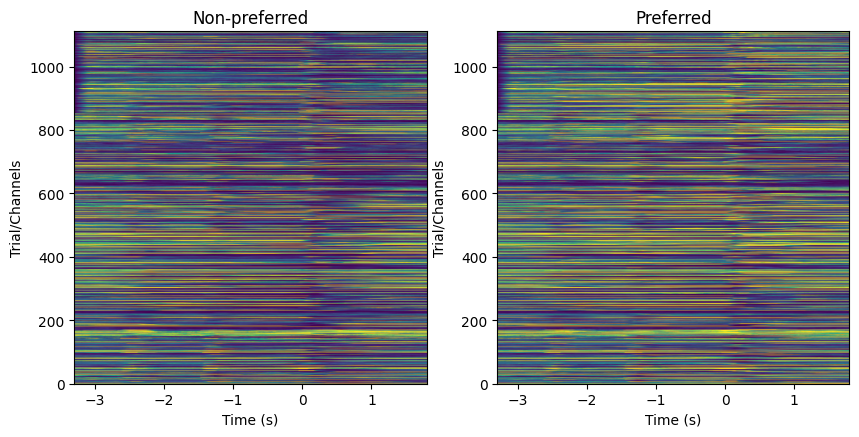

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].imshow(NOT_PREFERENCE, extent=[TIME[0], TIME[-1], 0, NOT_PREFERENCE.shape[0]],
             vmin=0, vmax=10, origin='upper')
ax[0].set_aspect(1/ax[0].get_data_ratio())
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Trial/Channels')
ax[0].set_title('Non-preferred')

ax[1].imshow(PREFERENCE, extent=[TIME[0], TIME[-1], 0, PREFERENCE.shape[0]],
             vmin=0, vmax=10, origin='upper')
ax[1].set_aspect(1/ax[1].get_data_ratio())
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Trial/Channels')
ax[1].set_title('Preferred')
plt.show()

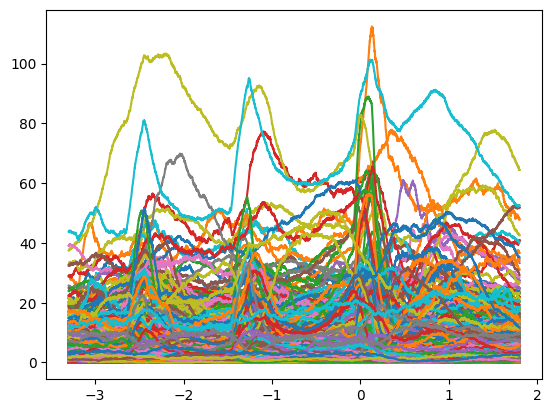

In [12]:
plt.plot(TIME, NOT_PREFERENCE.T)
plt.show()

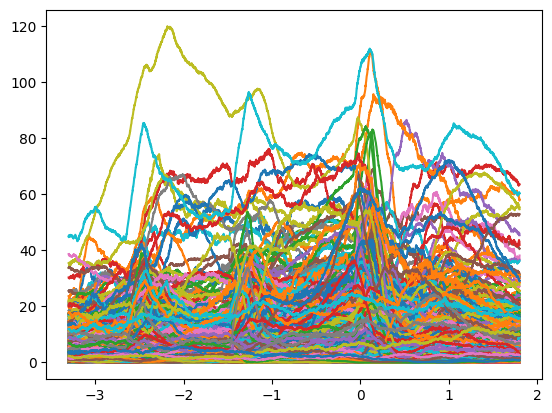

In [13]:
plt.plot(TIME, PREFERENCE.T)
plt.show()


In [14]:
NOT_PREFERENCE = NOT_PREFERENCE[np.isfinite(NOT_PREFERENCE[:,0]),:]
CHANNEL_INDEX = CHANNEL_INDEX[np.isfinite(PREFERENCE[:,0])]
PREFERENCE = PREFERENCE[np.isfinite(PREFERENCE[:,0]),:]


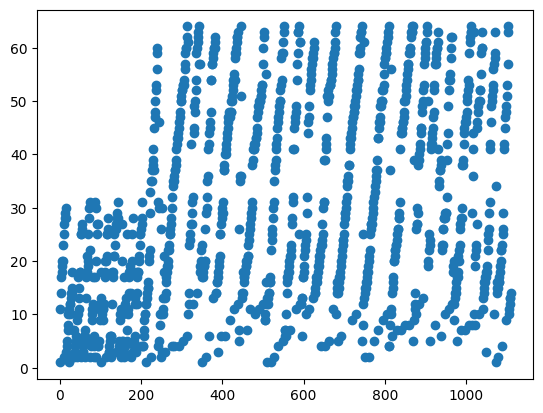

In [15]:
plt.plot(CHANNEL_INDEX, 'o')

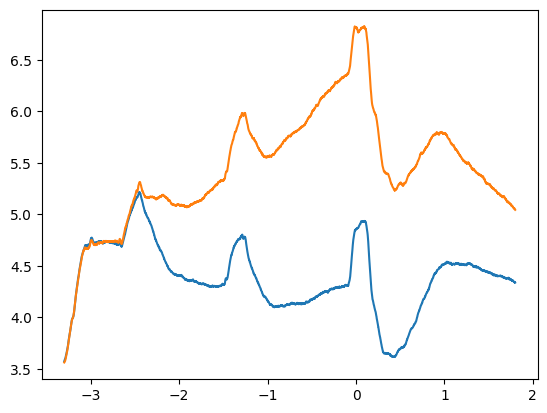

In [16]:
plt.plot(TIME, np.mean(NOT_PREFERENCE, axis=0), label='Non Preference')
plt.plot(TIME, np.mean(PREFERENCE, axis=0), label='Preference')
plt.show()

Create Channel Covariance Matrix

In [17]:
NUMBER_OF_CHANNELS = np.max(CHANNEL_INDEX)

CHANNELS_HAVE_NO_PREFERENCE = np.zeros((NUMBER_OF_CHANNELS, len(TIME)))
CHANNELS_HAVE_PREFERENCE = np.zeros((NUMBER_OF_CHANNELS, len(TIME)))

for i in range(1, NUMBER_OF_CHANNELS+1):
  CHANNELS_HAVE_NO_PREFERENCE[i-1,:] = np.mean(NOT_PREFERENCE[CHANNEL_INDEX==i, :], axis=0)
  CHANNELS_HAVE_PREFERENCE[i-1,:] = np.mean(PREFERENCE[CHANNEL_INDEX==i, :], axis=0)

print(CHANNELS_HAVE_NO_PREFERENCE.shape)

(64, 5101)


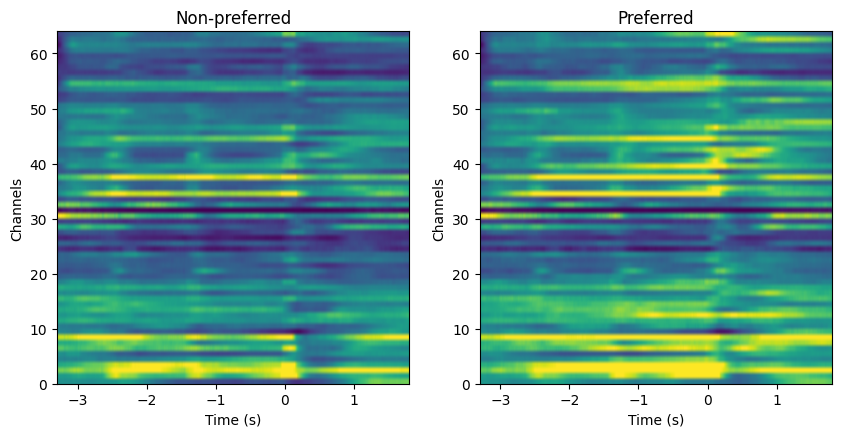

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].imshow(CHANNELS_HAVE_NO_PREFERENCE, extent=[TIME[0], TIME[-1], 0, NUMBER_OF_CHANNELS],
             vmin=0, vmax=10, origin='upper')
ax[0].set_aspect(1/ax[0].get_data_ratio())
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Channels')
ax[0].set_title('Non-preferred')

ax[1].imshow(CHANNELS_HAVE_PREFERENCE, extent=[TIME[0], TIME[-1], 0, NUMBER_OF_CHANNELS],
             vmin=0, vmax=10, origin='upper')
ax[1].set_aspect(1/ax[1].get_data_ratio())
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Channels')
ax[1].set_title('Preferred')
plt.show()

Compute Covariance Matrices

In [19]:
COVARIANCE_MATRIX_NO_PREFERENCE = np.cov(CHANNELS_HAVE_NO_PREFERENCE)
COVARIANCE_MATRIX_PREFERENCE = np.cov(CHANNELS_HAVE_PREFERENCE)
COVARIANCE_MATRIX_AVERAGE = (COVARIANCE_MATRIX_NO_PREFERENCE + COVARIANCE_MATRIX_PREFERENCE)/2



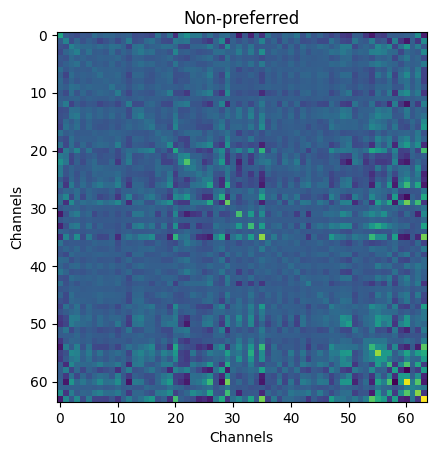

In [20]:
plt.imshow(COVARIANCE_MATRIX_NO_PREFERENCE)
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.title('Non-preferred')
plt.show()


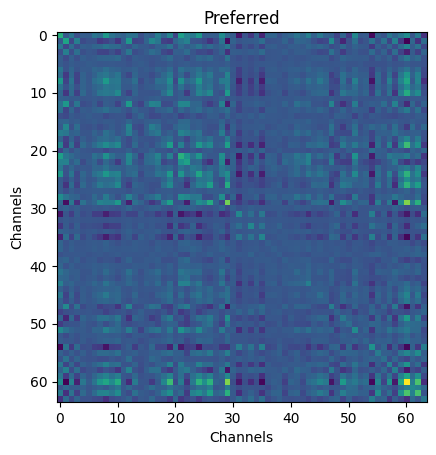

In [21]:
plt.imshow(COVARIANCE_MATRIX_PREFERENCE)
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.title('Preferred')
plt.show()

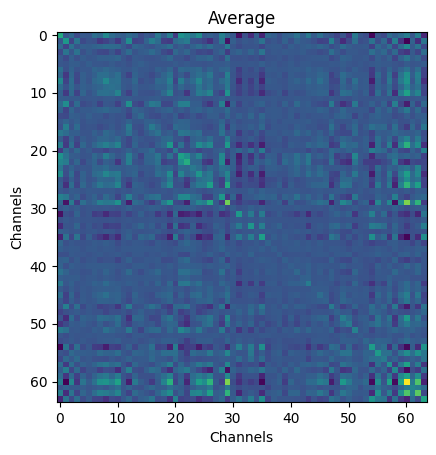

In [22]:
plt.imshow(COVARIANCE_MATRIX_AVERAGE)
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.title('Average')
plt.show()

In [24]:
evals, evecs = np.linalg.eigh(COVARIANCE_MATRIX_AVERAGE)
evals

array([1.19220888e-03, 1.82960313e-03, 1.98752120e-03, 2.36221509e-03,
       2.72635790e-03, 2.94226372e-03, 3.23408311e-03, 3.74054198e-03,
       3.94066205e-03, 4.13811541e-03, 4.52469042e-03, 4.89325191e-03,
       5.36221410e-03, 6.47534970e-03, 6.91971262e-03, 7.04825032e-03,
       7.33634553e-03, 8.27233246e-03, 9.29968518e-03, 1.11163288e-02,
       1.18902083e-02, 1.22093433e-02, 1.43426081e-02, 1.56267205e-02,
       1.66123270e-02, 1.78417679e-02, 1.93809369e-02, 2.02527501e-02,
       2.31866693e-02, 2.65605059e-02, 2.79582355e-02, 3.13823891e-02,
       3.21707885e-02, 3.74090284e-02, 4.58473700e-02, 5.32540942e-02,
       6.05237164e-02, 6.43330572e-02, 7.23977894e-02, 8.28741240e-02,
       8.92402042e-02, 1.06937349e-01, 1.19640882e-01, 1.58930204e-01,
       1.87586524e-01, 2.10405554e-01, 2.77966112e-01, 2.95607963e-01,
       3.27276342e-01, 3.82553723e-01, 5.16801705e-01, 6.38730912e-01,
       7.29677831e-01, 9.22260661e-01, 1.02347617e+00, 1.14890922e+00,
      

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_10047/1885910756.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda$')


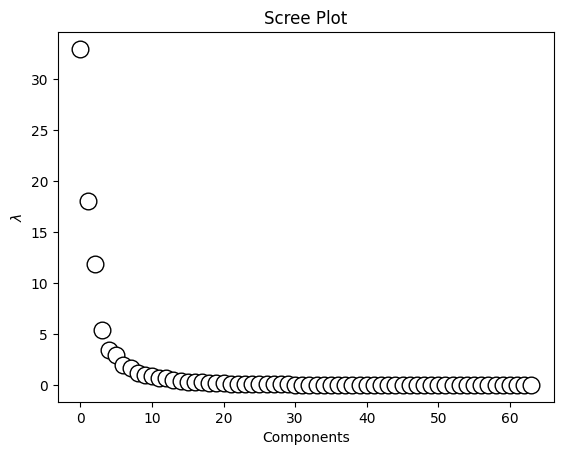

In [38]:
sidx = np.argsort(evals)[::-1]
evals = evals[sidx]
evecs = evecs[:,sidx]

plt.plot(evals, 'ko', markerfacecolor='w' , markersize=12)
plt.xlabel('Components')
plt.ylabel('$\lambda$')
plt.title('Scree Plot')
plt.show()

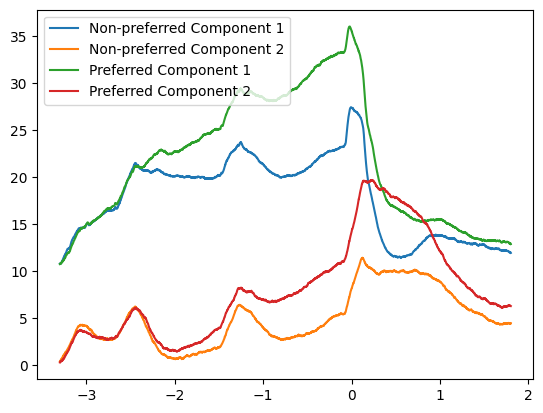

In [45]:
for i in range(2):
  # Find the largest component magnitude
  maxi = np.argmax(abs(evecs[:,i]))
  evecs[:,i] *= np.sign(evecs[maxi,i])

# Compute the Principle Component time series
pcNopr = evecs[:,0:2].T @ CHANNELS_HAVE_NO_PREFERENCE
pcPref = evecs[:,0:2].T @ CHANNELS_HAVE_PREFERENCE

plt.plot(TIME, pcNopr.T, TIME, pcPref.T)
plt.legend(['Non-preferred Component 1', 'Non-preferred Component 2', 'Preferred Component 1', 'Preferred Component 2'])
plt.show()


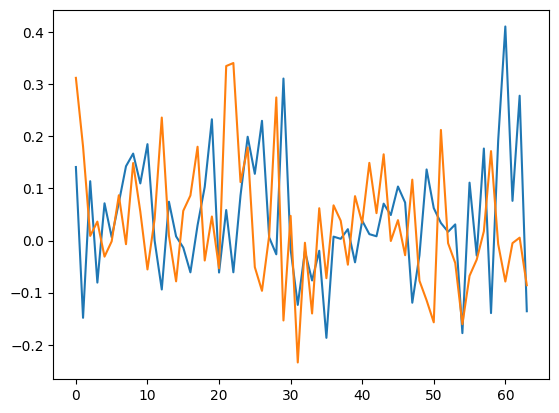

In [47]:
plt.plot(evecs[:,0:2])

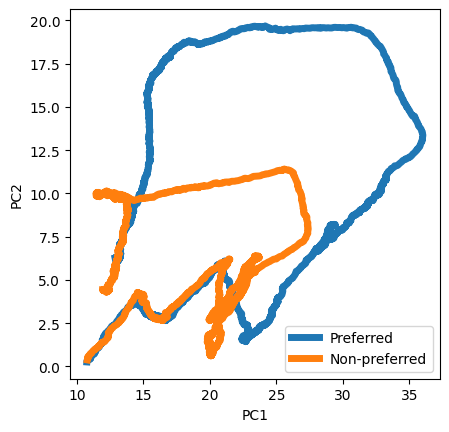

In [51]:
# Creating the State-Space Trajectories

plt.plot(pcPref[0,:], pcPref[1,:], linewidth=5, label='Preferred')
plt.plot(pcNopr[0,:], pcNopr[1,:], linewidth=5, label='Non-preferred')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.legend()
plt.show()

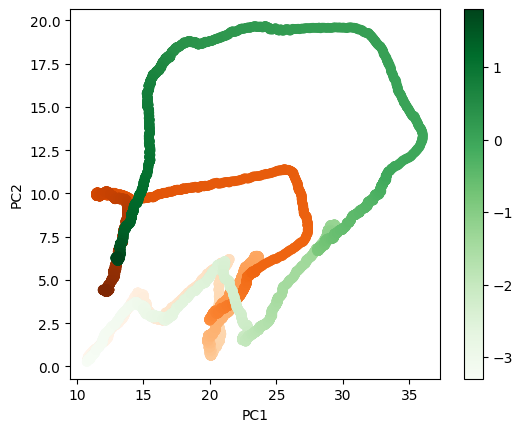

In [58]:
# Draw time using hues

plt.scatter(pcNopr[0,:], pcNopr[1,:], cmap='Oranges', c=TIME)
plt.scatter(pcPref[0,:], pcPref[1,:], cmap='Greens', c=TIME)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()